#Import Libraries and connect with google drive

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive


# Load Dataset

In [ ]:
data = pd.read_csv('/content/sample_data/Predict Students Dropout & Academic Success.csv')
print(data.head(10))
print(data.tail(10))

   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   
5               2                39                  1    9991   
6               1                 1                  1    9500   
7               1                18                  4    9254   
8               1                 1                  3    9238   
9               1                 1                  1    9238   

   Daytime/evening attendance\t  Previous qualification  \
0                             1                       1   
1                             1                       1   
2                             1                       1   
3                             1      

# Information of Dataset

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

# Description of Dataset

In [ ]:
print(data.describe())
print("---------------------------------------------------")
print(data['Marital status'].describe())

       Marital status  Application mode  Application order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime/evening attendance\t  Previous qualification  \
count                   4424.000000             4424.000000   
mean                       0.890823                4.577758   
std                        0.311897               10.216592   
min                        0.000000                1.000000   
25%      

Description of CSV file

# Check the Null Value

In [ ]:
print(data.isnull().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

Check is there any empty value or not

# Duplicate Row

In [ ]:
data_duplicate = data[data.duplicated()]
print(data_duplicate)

Empty DataFrame
Columns: [Marital status, Application mode, Application order, Course, Daytime/evening attendance	, Previous qualification, Previous qualification (grade), Nacionality, Mother's qualification, Father's qualification, Mother's occupation, Father's occupation, Admission grade, Displaced, Educational special needs, Debtor, Tuition fees up to date, Gender, Scholarship holder, Age at enrollment, International, Curricular units 1st sem (credited), Curricular units 1st sem (enrolled), Curricular units 1st sem (evaluations), Curricular units 1st sem (approved), Curricular units 1st sem (grade), Curricular units 1st sem (without evaluations), Curricular units 2nd sem (credited), Curricular units 2nd sem (enrolled), Curricular units 2nd sem (evaluations), Curricular units 2nd sem (approved), Curricular units 2nd sem (grade), Curricular units 2nd sem (without evaluations), Unemployment rate, Inflation rate, GDP, Target]
Index: []

[0 rows x 37 columns]


Just check is there any collumn with same sort of values

# Calculate Basic statistical data on Independent Variables

In [ ]:
numerical_columns = [
    'Age at enrollment',
    'Admission grade',
    'Previous qualification (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

for i in numerical_columns:
    if i in data.columns:
        print(f"\n--- {i} ---")
        print(f"Mean: {data[i].mean():.2f}")
        print(f"Median: {data[i].median():.2f}")
        print(f"Mode: {data[i].mode().values[0]}")
        print(f"Standard Deviation: {data[i].std():.2f}")
        print(f"Variance: {data[i].var():.2f}")
        print(f"Range: {data[i].max() - data[i].min():.2f}")



--- Age at enrollment ---
Mean: 23.27
Median: 20.00
Mode: 18
Standard Deviation: 7.59
Variance: 57.57
Range: 53.00

--- Admission grade ---
Mean: 126.98
Median: 126.10
Mode: 130.0
Standard Deviation: 14.48
Variance: 209.73
Range: 95.00

--- Previous qualification (grade) ---
Mean: 132.61
Median: 133.10
Mode: 133.1
Standard Deviation: 13.19
Variance: 173.93
Range: 95.00

--- Curricular units 1st sem (grade) ---
Mean: 10.64
Median: 12.29
Mode: 0.0
Standard Deviation: 4.84
Variance: 23.46
Range: 18.88

--- Curricular units 2nd sem (grade) ---
Mean: 10.23
Median: 12.20
Mode: 0.0
Standard Deviation: 5.21
Variance: 27.15
Range: 18.57


# Histogram of Curricular units 1st sem (grade) and Curricular units 2nd sem (grade)

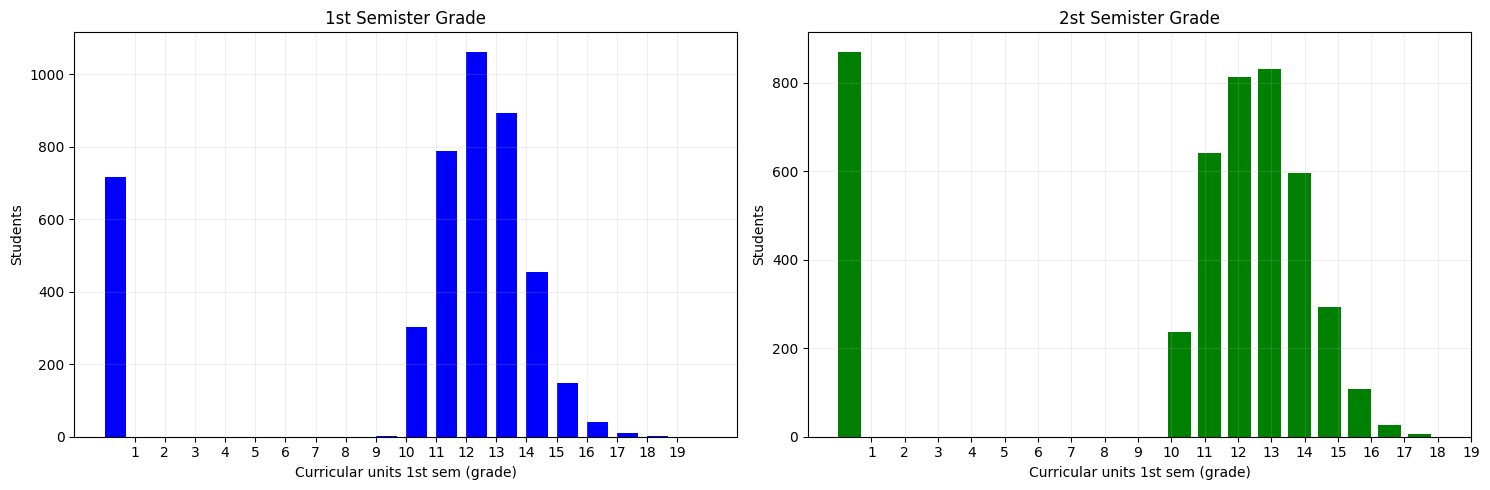

In [ ]:
x1 = data['Curricular units 1st sem (grade)']
x2 = data['Curricular units 2nd sem (grade)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))

ax1.hist(x1,bins = 20, range = (0, 20), width = 0.7, color="b")
ax1.set_title("1st Semister Grade")
ax1.set_xlabel("Curricular units 1st sem (grade)")
ax1.set_ylabel("Students")
ax1.set_xticks(range(1, 20, 1))
ax1.grid(True, alpha = 0.2)


ax2.hist(x2, bins = 20, range = (0, 18), width = 0.7, color="g")
ax2.set_title("2st Semister Grade")
ax2.set_xlabel("Curricular units 1st sem (grade)")
ax2.set_ylabel("Students")
ax2.set_xticks(range(1, 20, 1))
ax2.grid(True, alpha = 0.2)


plt.tight_layout()
plt.show()

# Scholarship Holders

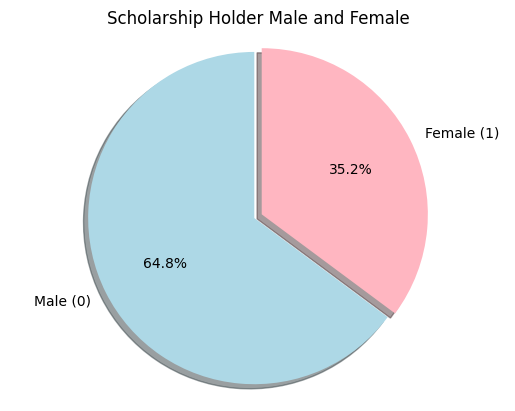

=== Scholarship Holder ===
Male: 2868 
Female: 1556


In [ ]:
gender_counts = data['Gender'].value_counts()


labels = ['Male (0)', 'Female (1)']
colors = ['lightblue', 'lightpink']
explode = (0.05, 0)


plt.pie(gender_counts.values, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90, shadow=True)
plt.title('Scholarship Holder Male and Female')
plt.axis('equal')
plt.show()


print("=== Scholarship Holder ===")
count_male = gender_counts[0]
count_female = gender_counts[1]
print(f"Male: {count_male} \nFemale: {count_female}")

The significant disparity in scholarship distribution, with 2,868 male recipients compared to 1,556 female recipients.

# Gender vs Dropout

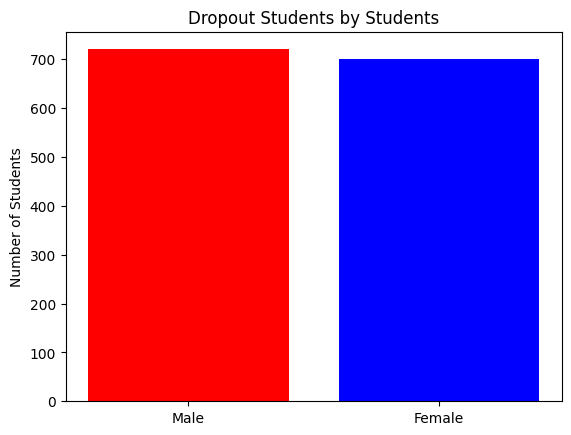

Male Dropout: 720
Female Dropout: 701


In [ ]:
# Count students
male_dropout = len(data[(data['Gender'] == 0) & (data['Target'] == 'Dropout')])
female_dropout = len(data[(data['Gender'] == 1) & (data['Target'] == 'Dropout')])

# Simple bar chart
counts = [male_dropout, female_dropout]
categories = ['Male', 'Female']


plt.bar(categories, counts, color=['red', 'blue'])
plt.ylabel('Number of Students')
plt.title('Dropout Students by Students')
plt.show()

print(f"Male Dropout: {male_dropout}")
print(f"Female Dropout: {female_dropout}")

Male students show slightly higher dropout rates compared to female students (701), suggests that dropout behavior is relatively consistent across genders.

# Age and Target distrubution

/tmp/ipython-input-4093181933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Target', y='Age at enrollment',palette = color ,showmeans=True)


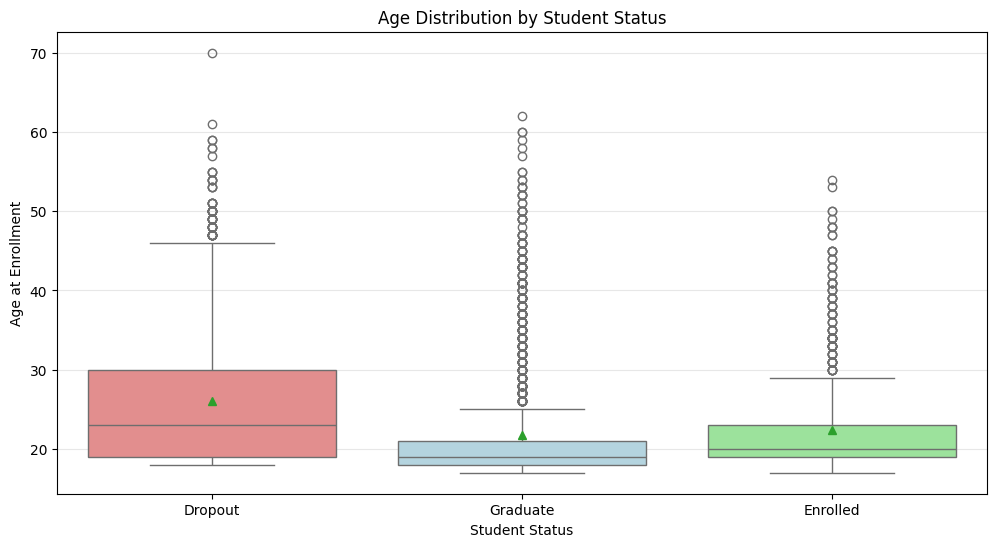

In [ ]:
plt.figure(figsize=(12, 6))
color = ['lightcoral', 'lightblue', 'lightgreen']
sns.boxplot(data=data, x='Target', y='Age at enrollment',palette = color ,showmeans=True)
plt.title('Age Distribution by Student Status')
plt.xlabel('Student Status')
plt.ylabel('Age at Enrollment')
plt.grid(axis='y', alpha=0.3)
plt.show()

This box plot visualizes the age distribution of students at enrollment, categorized by their academic status as dropouts, graduates, or currently enrolled.

# Target Distribution

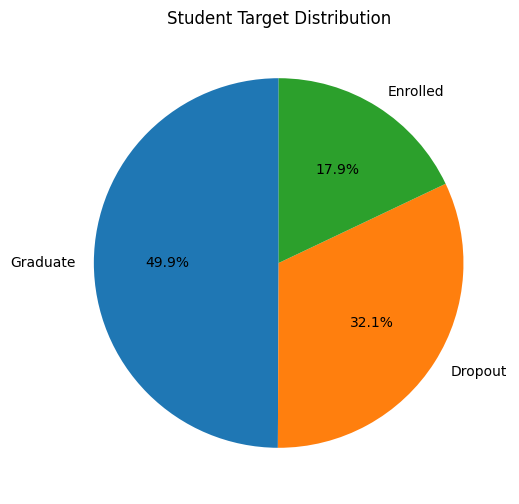

=== Target Distribution ===
Graduate: 2209 students (49.9%)
Dropout: 1421 students (32.1%)
Enrolled: 794 students (17.9%)


In [ ]:
target_counts = data['Target'].value_counts()


plt.figure(figsize=(8, 6))
plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Student Target Distribution')
plt.show()


print("=== Target Distribution ===")
for target, count in target_counts.items():
    percentage = (count / len(data)) * 100
    print(f"{target}: {count} students ({percentage:.1f}%)")

The number of 1,421 (32.1%) dropouts indicates significant challenges in student retention.

# Scholarship Status for Dropout Students

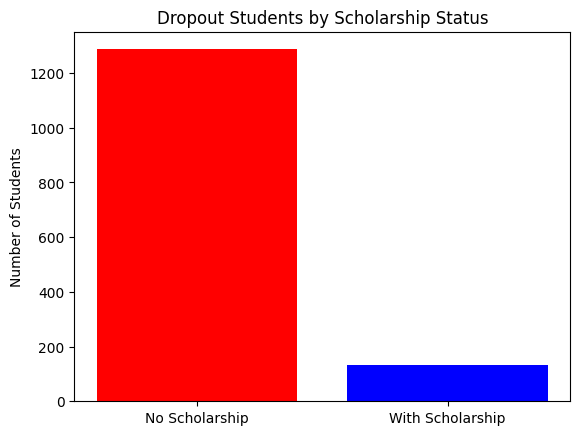

No Scholarship: 1287
With Scholarship: 134


In [ ]:

# Count students
no_scholarship_dropout = len(data[(data['Scholarship holder'] == 0) & (data['Target'] == 'Dropout')])
with_scholarship_dropout = len(data[(data['Scholarship holder'] == 1) & (data['Target'] == 'Dropout')])

# Simple bar chart
counts = [no_scholarship_dropout, with_scholarship_dropout]
categories = ['No Scholarship', 'With Scholarship']


plt.bar(categories, counts, color=['red', 'blue'])
plt.ylabel('Number of Students')
plt.title('Dropout Students by Scholarship Status')
plt.show()

print(f"No Scholarship: {no_scholarship_dropout}")
print(f"With Scholarship: {with_scholarship_dropout}")

Students who receive scholarships have significantly lower dropout rates than those without financial support. The substantial difference (1,287 vs 134 dropouts) strongly suggests that financial assistance plays a crucial role in student retention and academic persistence

# Why student Don't Grab Scholarship?

Bellow Mean No Scholarship Dropout: 564
Bellow Mean Scholarship Dropout: 41
Uppder Mean No Scholarship Dropout: 504
Upper Mean Scholarship Dropout: 71


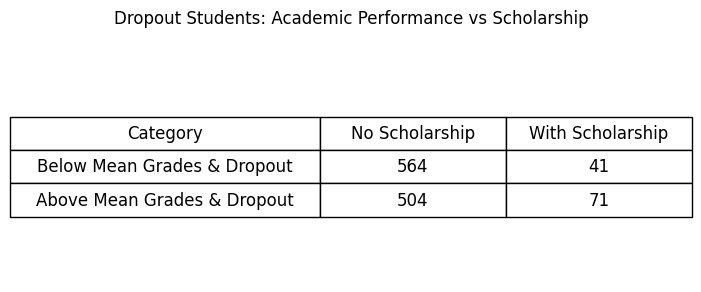

In [ ]:
mean_sem1 = data['Curricular units 1st sem (grade)'].mean()
mean_sem2 = data['Curricular units 2nd sem (grade)'].mean()

bellow_mean_No_Scholarship = len(data[
    (data['Target'] == 'Dropout') &
    (data['Scholarship holder'] == 0) &
    (data['Curricular units 1st sem (grade)'] < mean_sem1) &
    (data['Curricular units 2nd sem (grade)'] < mean_sem2)
    ])
bellow_mean_Scholarship = len(data[
    (data['Target'] == 'Dropout') &
    (data['Scholarship holder'] == 1) &
    (data['Curricular units 1st sem (grade)'] < mean_sem1) &
    (data['Curricular units 2nd sem (grade)'] < mean_sem2)
    ])


uppder_mean_No_Scholarship = len(data[
    (data['Target'] == 'Dropout')&
    (data['Scholarship holder'] == 0) &
    (data['Curricular units 1st sem (grade)'] > mean_sem1) &
    (data['Curricular units 2nd sem (grade)'] > mean_sem2)
    ])

uppder_mean_Scholarship = len(data[
    (data['Target'] == 'Dropout') &
    (data['Scholarship holder'] == 1) &
    (data['Curricular units 1st sem (grade)'] > mean_sem1) &
    (data['Curricular units 2nd sem (grade)'] > mean_sem2)
    ])

print(f"Bellow Mean No Scholarship Dropout: {bellow_mean_No_Scholarship}")
print(f"Bellow Mean Scholarship Dropout: {bellow_mean_Scholarship}")
print(f"Uppder Mean No Scholarship Dropout: {uppder_mean_No_Scholarship}")
print(f"Upper Mean Scholarship Dropout: {uppder_mean_Scholarship}")


data_table = [
    ['Category', 'No Scholarship', 'With Scholarship'],
    ['Below Mean Grades & Dropout', bellow_mean_No_Scholarship, bellow_mean_Scholarship],
    ['Above Mean Grades & Dropout', uppder_mean_No_Scholarship, uppder_mean_Scholarship]
]

# Create table
plt.figure(figsize=(8, 3))
table = plt.table(cellText=data_table,
                 loc='center',
                 cellLoc='center',
                 colWidths=[0.5, 0.3, 0.3])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

plt.axis('off')
plt.title('Dropout Students: Academic Performance vs Scholarship', pad=20)
plt.show()



The findings reveal that 564 non-scholarship students with below-average grades dropped out, compared to only 41 scholarship recipients in the same academic category. Interestingly, even among students with above-average academic performance, scholarship holders showed better retention rates (71 dropouts) compared to non-scholarship students (504 dropouts). This pattern suggests that financial assistance through scholarships significantly reduces dropout rates across all academic performance levels

# Reason behind lower semester grade

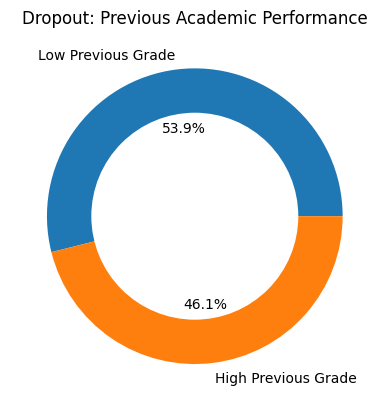

Low Previous Grade: 193
Upper Previous Grade: 165


In [ ]:
pre_qua_grade = data['Previous qualification (grade)'].mean()
admission_grade = data['Admission grade'].mean()

# print(f"Previous qualification (grade): {pre_qua_grade}")
# print(f"Admission grade: {admission_grade}")

bellow_pre_grade = len(data[
    (data['Target'] == 'Dropout') &
    (data['Scholarship holder'] == 0) &
    (data['Curricular units 1st sem (grade)'] < mean_sem1) &
    (data['Curricular units 2nd sem (grade)'] < mean_sem2) &
    (data['Previous qualification (grade)'] < pre_qua_grade) &
    (data['Admission grade'] < admission_grade)
    ])

upper_pre_grade = len(data[
    (data['Target'] == 'Dropout') &
    (data['Scholarship holder'] == 0) &
    (data['Curricular units 1st sem (grade)'] < mean_sem1) &
    (data['Curricular units 2nd sem (grade)'] < mean_sem2) &
    (data['Previous qualification (grade)'] > pre_qua_grade) &
    (data['Admission grade'] > admission_grade)
    ])


# Donut Chart
plt.pie([bellow_pre_grade, upper_pre_grade], labels=['Low Previous Grade and dropout', 'High Previous Grade and dropout'], autopct='%1.1f%%')
plt.gca().add_artist(plt.Circle((0,0), 0.70, fc='white'))
plt.title('Dropout: Previous Academic Performance')
plt.show()


print(f"Low Previous Grade: {bellow_pre_grade}")
print(f"Upper Previous Grade: {upper_pre_grade}")




Students with weaker previous academic backgrounds are more vulnerable to dropping out, even when controlling for current performance.